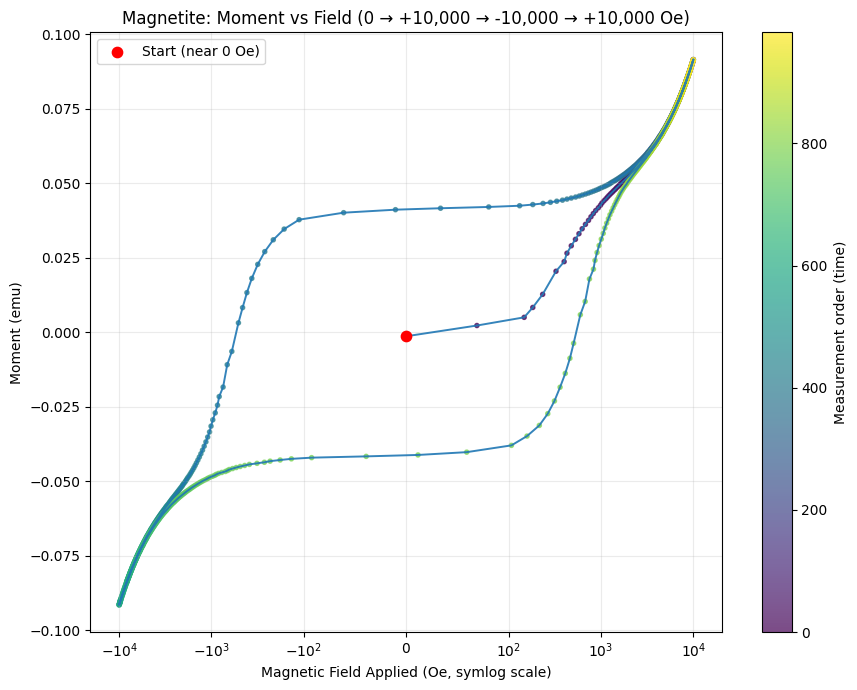

Loaded 983 valid points
Field range: -10000.3 to 10000.4 Oe


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Path to your VersaLab export
data_path = Path('/Users/joshuaclavecillas/Downloads/Magnetite 0 _ 10000 oe 300k-1.txt')

# Find the [Data] section and header row
lines = data_path.read_text(errors='ignore').splitlines()
data_idx = next(i for i, line in enumerate(lines) if line.strip() == '[Data]')
header = [h.strip() for h in lines[data_idx + 1].split(',')]

# Read numeric table (skip malformed lines safely)
df = pd.read_csv(
    data_path,
    skiprows=data_idx + 2,
    names=header,
    engine='python',
    on_bad_lines='skip'
)

# Keep only the columns we need
field = pd.to_numeric(df['Magnetic Field (Oe)'], errors='coerce')
moment = pd.to_numeric(df['Moment (emu)'], errors='coerce')
valid = field.notna() & moment.notna()
field = field[valid].to_numpy()
moment = moment[valid].to_numpy()

# Plot M(H) in acquisition order (time evolution)
fig, ax = plt.subplots(figsize=(9, 7))
ax.plot(field, moment, lw=1.4, color='tab:blue', alpha=0.9)

# Color points by measurement order to show sweep direction
idx = np.arange(len(field))
sc = ax.scatter(field, moment, c=idx, cmap='viridis', s=9, alpha=0.7)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Measurement order (time)')

# Use log-like scaling that supports positive and negative applied fields
# (full log scale cannot represent zero/negative values)
ax.set_xscale('symlog', linthresh=100)

ax.set_xlabel('Magnetic Field Applied (Oe, symlog scale)')
ax.set_ylabel('Moment (emu)')
ax.set_title('Magnetite: Moment vs Field (0 → +10,000 → -10,000 → +10,000 Oe)')
ax.grid(True, alpha=0.25, which='both')

# Mark the start point
ax.scatter(field[0], moment[0], color='red', s=55, zorder=5, label='Start (near 0 Oe)')
ax.legend(loc='best')

plt.tight_layout()
plt.show()

print(f'Loaded {len(field)} valid points')
print(f'Field range: {field.min():.1f} to {field.max():.1f} Oe')

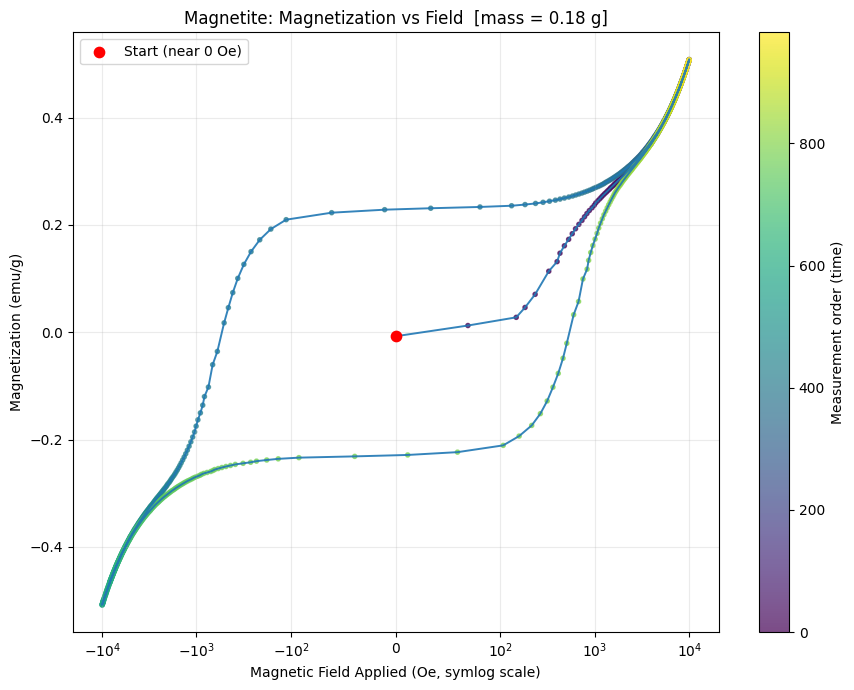

Sample mass            : 0.18 g
Max magnetization      : 0.5083 emu/g  (at H = 9989.2 Oe)
Min magnetization      : -0.5081 emu/g  (at H = -10000.3 Oe)
Saturation (approx)    : 0.5083 emu/g


In [6]:
# Magnetization from M(H) data (cell 1)
# field and moment arrays are already loaded above

SAMPLE_MASS_G = 0.18  # grams

# Magnetization M = moment / mass  [emu/g]
magnetization = moment / SAMPLE_MASS_G

# Plot magnetization vs applied field
fig2, ax2 = plt.subplots(figsize=(9, 7))
ax2.plot(field, magnetization, lw=1.4, color='tab:blue', alpha=0.9)

idx2 = np.arange(len(field))
sc2 = ax2.scatter(field, magnetization, c=idx2, cmap='viridis', s=9, alpha=0.7)
cbar2 = plt.colorbar(sc2, ax=ax2)
cbar2.set_label('Measurement order (time)')

ax2.set_xscale('symlog', linthresh=100)
ax2.set_xlabel('Magnetic Field Applied (Oe, symlog scale)')
ax2.set_ylabel('Magnetization (emu/g)')
ax2.set_title(f'Magnetite: Magnetization vs Field  [mass = {SAMPLE_MASS_G} g]')
ax2.grid(True, alpha=0.25, which='both')

ax2.scatter(field[0], magnetization[0], color='red', s=55, zorder=5, label='Start (near 0 Oe)')
ax2.legend(loc='best')

plt.tight_layout()
plt.show()

print(f'Sample mass            : {SAMPLE_MASS_G} g')
print(f'Max magnetization      : {magnetization.max():.4f} emu/g  (at H = {field[magnetization.argmax()]:.1f} Oe)')
print(f'Min magnetization      : {magnetization.min():.4f} emu/g  (at H = {field[magnetization.argmin()]:.1f} Oe)')
print(f'Saturation (approx)    : {abs(magnetization).max():.4f} emu/g')

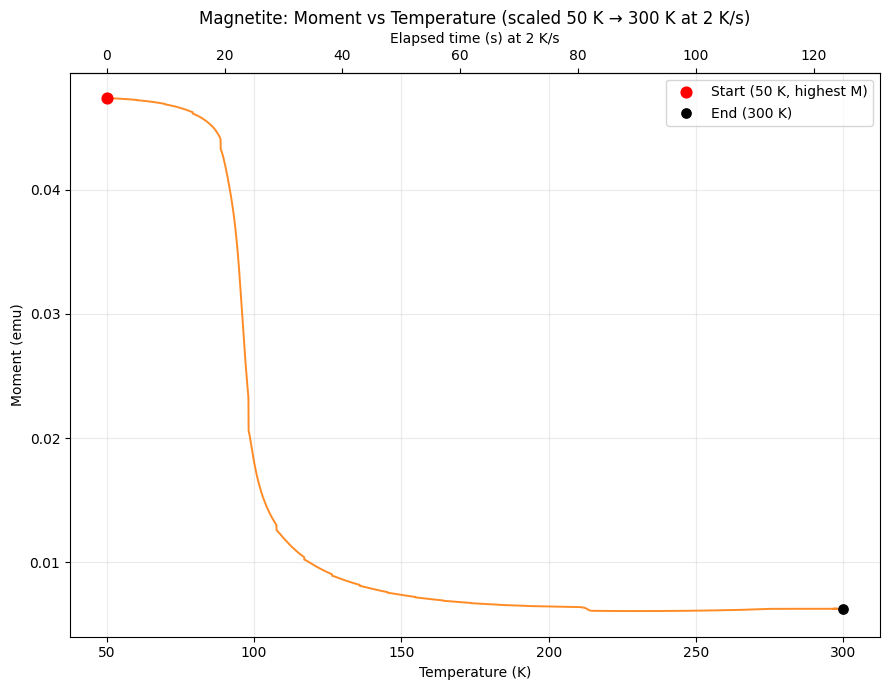

Loaded 7688 valid points
Scaled temperature range: 50.00 to 300.00 K
Heating duration at 2 K/s: 125.0 s (2.08 min)
Moment ordering adjusted so M(50 K) is highest: True


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Path to the VersaLab export
data_path_T = Path('/Users/joshuaclavecillas/Downloads/magnetite raw data 300 50k 1000 oe.txt')

# Requested rate
RATE_K_PER_S = 2.0
T_MIN, T_MAX = 50.0, 300.0

# Find the [Data] section and header row
lines_T = data_path_T.read_text(errors='ignore').splitlines()
data_idx_T = next(i for i, line in enumerate(lines_T) if line.strip() == '[Data]')
header_T = [h.strip() for h in lines_T[data_idx_T + 1].split(',')]

# Read numeric table safely
df_T = pd.read_csv(
    data_path_T,
    skiprows=data_idx_T + 2,
    names=header_T,
    engine='python',
    on_bad_lines='skip'
)

# Keep only Temperature and Moment
temp_raw = pd.to_numeric(df_T['Temperature (K)'], errors='coerce')
moment_raw = pd.to_numeric(df_T['Moment (emu)'], errors='coerce')
valid_T = temp_raw.notna() & moment_raw.notna()
temp_raw = temp_raw[valid_T].to_numpy()
moment_raw = moment_raw[valid_T].to_numpy()

# Order points from low to high temperature, then force 50 K to be highest moment
order = np.argsort(temp_raw)
temp_sorted = temp_raw[order]
moment_sorted = moment_raw[order]

moment_reversed_to_match_50K_high = False
if moment_sorted[0] < moment_sorted[-1]:
    moment_sorted = moment_sorted[::-1]
    moment_reversed_to_match_50K_high = True

# Build a perfectly scaled temperature axis: starts at 50 K and increases by 2 K every second
est_duration_s = (T_MAX - T_MIN) / RATE_K_PER_S
time_s = np.linspace(0.0, est_duration_s, len(moment_sorted))
temp_scaled = T_MIN + RATE_K_PER_S * time_s

# Plot M(T) with corrected scaling
fig_T, ax_T = plt.subplots(figsize=(9, 7))
ax_T.plot(temp_scaled, moment_sorted, lw=1.4, color='tab:orange', alpha=0.9)

ax_T.set_xlabel('Temperature (K)')
ax_T.set_ylabel('Moment (emu)')
ax_T.set_title('Magnetite: Moment vs Temperature (scaled 50 K → 300 K at 2 K/s)')
ax_T.grid(True, alpha=0.25)

# Markers
ax_T.scatter(temp_scaled[0], moment_sorted[0], color='red', s=60, zorder=5, label='Start (50 K, highest M)')
ax_T.scatter(temp_scaled[-1], moment_sorted[-1], color='black', s=45, zorder=5, label='End (300 K)')
ax_T.legend(loc='best')

# Top axis: elapsed time (already linear with scaling)
def temp_to_time(T):
    return (np.asarray(T) - T_MIN) / RATE_K_PER_S

def time_to_temp(t):
    return T_MIN + RATE_K_PER_S * np.asarray(t)

secax = ax_T.secondary_xaxis('top', functions=(temp_to_time, time_to_temp))
secax.set_xlabel('Elapsed time (s) at 2 K/s')

plt.tight_layout()
plt.show()

print(f'Loaded {len(temp_scaled)} valid points')
print(f'Scaled temperature range: {temp_scaled.min():.2f} to {temp_scaled.max():.2f} K')
print(f'Heating duration at 2 K/s: {est_duration_s:.1f} s ({est_duration_s/60:.2f} min)')
print(f'Moment ordering adjusted so M(50 K) is highest: {moment_reversed_to_match_50K_high}')